# Regression - Custom Project

- Author: Tulsi
- Date: 2026-07
- Dataset: Medical insurance charges (insurance.csv)
- Target: charges
- Source: Choi, M. (2018). Medical Cost Personal Datasets. Kaggle.
  <https://www.kaggle.com/datasets/mirichoi0218/insurance> (ODbL v1.0)

Run all cells top to bottom (**Run All**) before pushing to GitHub.

## Overview

This project predicts individual medical insurance charges from six features:
age, bmi, children, sex, smoker, and region. Charges is a numeric target, so
this is a supervised regression problem.

The notebook encodes the categorical features, fits and evaluates a linear model
with R-squared, RMSE, and a residual plot, then works to improve it: a log
transform for the skewed target, polynomial features for the interactions the
linear model misses, and Ridge and ElasticNet regularization to control
overfitting.

## Section 0. When to Use Regression, and How We Judge It

Use **regression** when the target is a **number**: charges, price, temperature,
demand. (A category target is classification, Module 3.)

We judge a regression on held-out data, with:

- **R-squared** - the fraction of the variation in the target the model explains
  (roughly 0 to 1; higher is more).
- **RMSE** - root mean squared error, the typical size of a miss, in the target's units.
- **residual plot** - actual minus predicted. If the model fits well, residuals
  scatter randomly around zero with no pattern. A curve or a funnel says the model
  is the wrong shape - itself a useful finding.

**Over- vs. under-fitting:** a model too simple **underfits** (misses real structure;
poor on both train and test). A model too complex **overfits** (memorizes the training
data; great on train, worse on test). You detect it by comparing train and test error
as complexity changes - Section 6.

## Section 1. Project Setup and Imports

In [26]:
# === Section 1a. DECLARE IMPORTS ===

from importlib.metadata import version  # to verify
import logging  # for type hinting
import platform  # to verify
from typing import Final  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import ElasticNetCV, LinearRegression, RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("M04 Phase 5", level="DEBUG")
log_header(LOG, "M04 Phase 5")

# === Section 1c. USE THE LOGGER TO VERIFY IMPORTS ===

# If any do NOT return a version number, then that package is not installed correctly.
# Check your pyproject.toml and re-run environment setup commands.

LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {version('pandas')}")
LOG.info(f"  numpy:        {version('numpy')}")
LOG.info(f"  scikit-learn: {version('scikit-learn')}")
LOG.info(f"  seaborn:      {version('seaborn')}")
LOG.info(f"  matplotlib:   {version('matplotlib')}")

# === Section 1d. SET PANDAS DISPLAY CONFIGURATION (helps in notebooks) ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

2026-07-24 21:21:37 | INFO | M04 Phase 5 | === RUN START ===
2026-07-24 21:21:37 | INFO | M04 Phase 5 | project=M04 Phase 5
2026-07-24 21:21:37 | INFO | M04 Phase 5 | repo_dir=ml-04-regression
2026-07-24 21:21:37 | INFO | M04 Phase 5 | python=3.14.2
2026-07-24 21:21:37 | INFO | M04 Phase 5 | os=Windows 11
2026-07-24 21:21:37 | INFO | M04 Phase 5 | shell=powershell
2026-07-24 21:21:37 | INFO | M04 Phase 5 | cwd=notebooks
2026-07-24 21:21:37 | INFO | M04 Phase 5 | github_actions=False
2026-07-24 21:21:37 | INFO | M04 Phase 5 | Confirming installation:
2026-07-24 21:21:37 | INFO | M04 Phase 5 |   python:       3.14.2
2026-07-24 21:21:37 | INFO | M04 Phase 5 |   pandas:       3.0.3
2026-07-24 21:21:37 | INFO | M04 Phase 5 |   numpy:        2.5.1
2026-07-24 21:21:37 | INFO | M04 Phase 5 |   scikit-learn: 1.9.0
2026-07-24 21:21:37 | INFO | M04 Phase 5 |   seaborn:      0.13.2
2026-07-24 21:21:37 | INFO | M04 Phase 5 |   matplotlib:   3.11.1


## Section 2. Load and Prepare the Data

In [27]:
# === Section 2. Load the Data ===

# The insurance dataset is a CSV in data/raw/.
# The path climbs from notebooks/ up to the repo root, then into data/raw/.
CSV_PATH: Final[str] = "../data/raw/insurance.csv"

df: pd.DataFrame = pd.read_csv(CSV_PATH)
LOG.info(f"Loaded: {df.shape[0]} rows (instances), {df.shape[1]} columns")

TARGET_COL: Final[str] = "charges"
TARGET_LABEL: Final[str] = "Charges (USD)"

2026-07-24 21:21:37 | INFO | M04 Phase 5 | Loaded: 1338 rows (instances), 7 columns


### Explore the Data

In [28]:
# === Explore the raw data before choosing features ===

LOG.info(f"Column types:\n{df.dtypes.to_string()}")
LOG.info(f"Missing values:\n{df.isna().sum().to_string()}")
LOG.info(f"\n{df.describe(include='all').round(2).to_string()}")
df.head(10)

2026-07-24 21:21:37 | INFO | M04 Phase 5 | Column types:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
2026-07-24 21:21:37 | INFO | M04 Phase 5 | Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
2026-07-24 21:21:37 | INFO | M04 Phase 5 | 
            age   sex      bmi  children smoker     region   charges
count   1338.00  1338  1338.00   1338.00   1338       1338   1338.00
unique      NaN     2      NaN       NaN      2          4       NaN
top         NaN  male      NaN       NaN     no  southeast       NaN
freq        NaN   676      NaN       NaN   1064        364       NaN
mean      39.21   NaN    30.66      1.09    NaN        NaN  13270.42
std       14.05   NaN     6.10      1.21    NaN        NaN  12110.01
min       18.00   NaN    15.96      0.00    NaN        NaN   1121.87
25%       27.00   NaN    26.30      0.00    NaN   

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [29]:
# Category values for the columns we will encode.
for col in ["sex", "smoker", "region"]:
    LOG.info(f"{col}: {df[col].unique().tolist()}")
    LOG.info(f"{df[col].value_counts().to_string()}")

2026-07-24 21:21:37 | INFO | M04 Phase 5 | sex: ['female', 'male']
2026-07-24 21:21:37 | INFO | M04 Phase 5 | sex
male      676
female    662
2026-07-24 21:21:37 | INFO | M04 Phase 5 | smoker: ['yes', 'no']
2026-07-24 21:21:37 | INFO | M04 Phase 5 | smoker
no     1064
yes     274
2026-07-24 21:21:37 | INFO | M04 Phase 5 | region: ['southwest', 'southeast', 'northwest', 'northeast']
2026-07-24 21:21:37 | INFO | M04 Phase 5 | region
southeast    364
southwest    325
northwest    325
northeast    324


In [30]:
# === Encode categorical columns as numeric ===
# get_dummies turns each category into 0/1 columns.
# drop_first avoids redundancy: for a 2-value column it leaves one column,
# and for region's 4 values it leaves 3, with the dropped value as baseline.
df_encoded: pd.DataFrame = pd.get_dummies(
    df, columns=["sex", "smoker", "region"], drop_first=True
)

# Convert the new True/False columns to 1/0 integers.
bool_cols = df_encoded.select_dtypes(bool).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

LOG.info(f"Columns after encoding: {list(df_encoded.columns)}")
LOG.info(f"\n{df_encoded.dtypes.to_string()}")
df_encoded.head()

2026-07-24 21:21:37 | INFO | M04 Phase 5 | Columns after encoding: ['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']
2026-07-24 21:21:37 | INFO | M04 Phase 5 | 
age                   int64
bmi                 float64
children              int64
charges             float64
sex_male              int64
smoker_yes            int64
region_northwest      int64
region_southeast      int64
region_southwest      int64


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


## Section 3. Split into Train and Test


ANALYST CHOICE

We hold out a test set the model never sees
so R-squared and RMSE reflect new data. 

Without a held-out set we cannot tell a good fit from memorization.

In [31]:
# === Section 3. Split into Train and Test ===

# CUSTOM: ANALYST CHOICE

# Reproducibility for the split and the model.
# Pick any integer, but keep it the same to get the same results.
RANDOM_STATE: Final[int] = 42

# Use every column except the target as a candidate feature.
# The case comparison in Section 5 tests which ones earn their place.
FEATURE_COLS: list[str] = [c for c in df_encoded.columns if c != TARGET_COL]
LOG.info(f"Feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}")

"""Build X (2-D) and y (1-D), then split into train and test.

WHY: scikit-learn wants X as shape (n, features) and y as shape (n,).

A list of column names gives a DataFrame (2-D);
a single name gives a Series (1-D).
"""

# Declare X to hold the feature values,
# which will be used for model fitting.
X: np.ndarray = df_encoded[FEATURE_COLS].to_numpy()

# Declare y to hold the target values,
# which will be used for model fitting.
y: np.ndarray = df_encoded[TARGET_COL].to_numpy()

# Declare X_train to hold the training feature values,
# which will be used for model fitting.
X_train: np.ndarray

# Declare X_test to hold the test feature values,
# which will be used for evaluation after model training.
X_test: np.ndarray

# Declare y_train to hold the training target values,
# which will be used for model fitting.
y_train: np.ndarray

# Declare y_test to hold the test target values,
# which will be used for evaluation after model training.
y_test: np.ndarray

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
LOG.info(f"X shape: {X.shape}  (rows, features)")
LOG.info(f"Train instances: {len(X_train)}")
LOG.info(f"Test instances: {len(X_test)}")

2026-07-24 21:21:37 | INFO | M04 Phase 5 | Feature columns (8): ['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']
2026-07-24 21:21:37 | INFO | M04 Phase 5 | X shape: (1338, 8)  (rows, features)
2026-07-24 21:21:37 | INFO | M04 Phase 5 | Train instances: 1070
2026-07-24 21:21:37 | INFO | M04 Phase 5 | Test instances: 268


## Section 4. Fit a Linear Model

In [32]:
# === Section 4. Fit a Linear Model ===


"""
Fit y = c1*x1 + c2*x2 + ... + intercept with scikit-learn.

WHY: create -> .fit() -> read results / .predict()
 is the same pattern for every scikit-learn model.

The model exposes .coef_ (one coefficient per feature) and .intercept_.
"""

LOG.info("Fitting a linear regression (scikit-learn)")

# create a linear regression model object (untrained)
model = LinearRegression()

# fit the model to the training data (learn the coefficients and intercept)
model.fit(X_train, y_train)

# retrieve the results (coefficients and intercept) and log them

coefficients: list[float] = [float(c) for c in model.coef_]
intercept: float = float(model.intercept_)

LOG.info(f"Fitted model for {TARGET_COL}:")
for name, c in zip(FEATURE_COLS, coefficients, strict=True):
    LOG.info(f"  {c:.6g} * {name}")
LOG.info(f"  intercept: {intercept:.6g}")

# Build the equation from the coefficient list so it works for any feature count.
equation: str = " + ".join(
    f"{c:.6g} * {name}" for name, c in zip(FEATURE_COLS, coefficients, strict=True)
)
LOG.info(f"Equation: {TARGET_COL} = {equation} + {intercept:.6g}")

2026-07-24 21:21:37 | INFO | M04 Phase 5 | Fitting a linear regression (scikit-learn)
2026-07-24 21:21:37 | INFO | M04 Phase 5 | Fitted model for charges:
2026-07-24 21:21:37 | INFO | M04 Phase 5 |   256.976 * age
2026-07-24 21:21:37 | INFO | M04 Phase 5 |   337.093 * bmi
2026-07-24 21:21:37 | INFO | M04 Phase 5 |   425.279 * children
2026-07-24 21:21:37 | INFO | M04 Phase 5 |   -18.5917 * sex_male
2026-07-24 21:21:37 | INFO | M04 Phase 5 |   23651.1 * smoker_yes
2026-07-24 21:21:37 | INFO | M04 Phase 5 |   -370.677 * region_northwest
2026-07-24 21:21:37 | INFO | M04 Phase 5 |   -657.864 * region_southeast
2026-07-24 21:21:37 | INFO | M04 Phase 5 |   -809.799 * region_southwest
2026-07-24 21:21:37 | INFO | M04 Phase 5 |   intercept: -11931.2
2026-07-24 21:21:37 | INFO | M04 Phase 5 | Equation: charges = 256.976 * age + 337.093 * bmi + 425.279 * children + -18.5917 * sex_male + 23651.1 * smoker_yes + -370.677 * region_northwest + -657.864 * region_southeast + -809.799 * region_southwest

## Section 5. Evaluate the Model Fit

2026-07-24 21:21:37 | INFO | M04 Phase 5 | Fit numbers on the TEST set (for you to interpret):
2026-07-24 21:21:37 | INFO | M04 Phase 5 |   R-squared: 0.7836
2026-07-24 21:21:37 | INFO | M04 Phase 5 |   RMSE:      5796.28  (in units of Charges (USD))


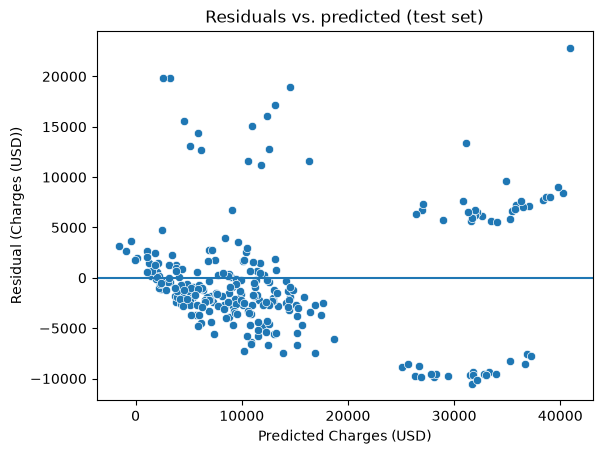

In [33]:
# === Section 5. Evaluate the Model Fit ===

# With regression, we use  R-squared, RMSE, and Residuals

"""
Report test R-squared and RMSE, and show a residual plot.

WHY: These are how the analyst decides
whether the model is a fair description.

This reports them on held-out data;
it does NOT declare the fit good or bad.

The analyst uses the numbers and the residual plot to decide.
"""

y_hat: np.ndarray = model.predict(X_test)

# Use float() to convert from numpy types to native Python types
residuals: np.ndarray = y_test - y_hat
r_squared: float = float(model.score(X_test, y_test))
rmse: float = float(np.sqrt(np.mean(residuals**2)))

LOG.info("Fit numbers on the TEST set (for you to interpret):")
LOG.info(f"  R-squared: {r_squared:.4f}")
LOG.info(f"  RMSE:      {rmse:.6g}  (in units of {TARGET_LABEL})")

# Residual plot: random scatter around 0 means the linear model fits well.

# Start a new figure
plt.figure()

# Create a scatter plot of residuals vs. predicted values
sns.scatterplot(x=y_hat, y=residuals)

# Add a horizontal line at y=0 to help visualize the residuals
plt.axhline(0)

# Label the axes and add a title
plt.xlabel(f"Predicted {TARGET_LABEL}")
plt.ylabel(f"Residual ({TARGET_LABEL})")
plt.title("Residuals vs. predicted (test set)")

# save the figure for the README, then show it
plt.savefig("../docs/images/residuals_insurance.png", dpi=150, bbox_inches="tight")

# show the plot
plt.show()

### Interpretation

The residuals are not random. They show three patterns, and each one is
diagnostic.

First, the spread widens as predicted charges rise. From low predictions to
about 20,000, the residuals fan outward rather than staying an even band. This
is heteroscedasticity, the error growing with the predicted value, and it is the
signature of a right-skewed target. The model is least reliable exactly where
charges are highest.

Second, at high predicted charges the points split into two parallel bands with
a gap between them. Since being a smoker adds about 23,650 to the prediction,
these high-prediction cases are mostly smokers, and the two bands suggest the
effect of bmi differs between smokers and non-smokers. A plain linear model
cannot represent that interaction, so it splits the difference and misses both
groups.

Third, a few points at low predictions have large positive residuals: real
charges far above what the features suggested.

Test R-squared is 0.7836, but a typical miss is 5,796 dollars against a mean
charge of 13,270. The high R-squared does not mean the model is adequate. The
residual structure shows two specific problems, the skew in charges and the
smoking and bmi interaction, and the next sections address each one.

### Section 5b. Transform the Target

2026-07-24 21:21:37 | INFO | M04 Phase 5 | Log-target model, evaluated back in dollars:
2026-07-24 21:21:37 | INFO | M04 Phase 5 |   R-squared (log space): 0.8047
2026-07-24 21:21:37 | INFO | M04 Phase 5 |   RMSE (dollars):        7814.064


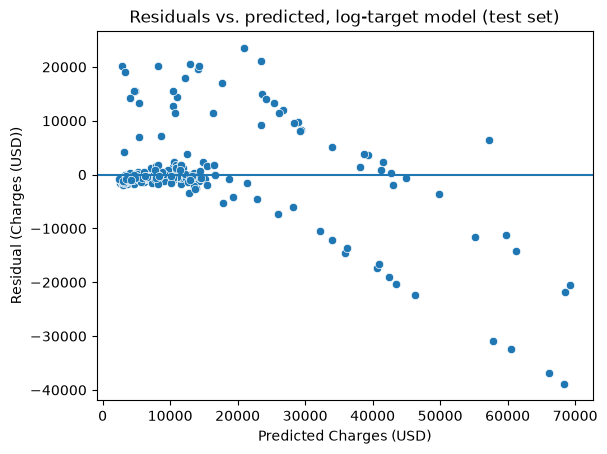

In [34]:
# === Section 5b. Transform the Target ===

"""Refit on log(charges) to address the funnel in the residuals.

WHY: charges is right-skewed, so the error grows with the prediction.
Modeling log(charges) compresses the tail. We convert predictions back to
dollars with np.exp() so RMSE stays comparable to the untransformed model.
"""

# np.log1p is log(1 + x); np.expm1 reverses it. Safe even if a charge were 0.
y_train_log: np.ndarray = np.log1p(y_train)
y_test_log: np.ndarray = np.log1p(y_test)

log_model = LinearRegression().fit(X_train, y_train_log)

# Predict in log space, then convert back to dollars to evaluate.
y_hat_log: np.ndarray = log_model.predict(X_test)
y_hat_dollars: np.ndarray = np.expm1(y_hat_log)

log_residuals: np.ndarray = y_test - y_hat_dollars
log_r2: float = float(log_model.score(X_test, y_test_log))
log_rmse: float = float(np.sqrt(np.mean(log_residuals**2)))

LOG.info("Log-target model, evaluated back in dollars:")
LOG.info(f"  R-squared (log space): {log_r2:.4f}")
LOG.info(f"  RMSE (dollars):        {log_rmse:.3f}")

# Residual plot in dollars, to compare with the untransformed plot above.
plt.figure()
sns.scatterplot(x=y_hat_dollars, y=log_residuals)
plt.axhline(0)
plt.xlabel(f"Predicted {TARGET_LABEL}")
plt.ylabel(f"Residual ({TARGET_LABEL})")
plt.title("Residuals vs. predicted, log-target model (test set)")
plt.savefig("../docs/images/residuals_insurance_log.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation

The log transform is a mixed result. Its R-squared of 0.8047 is measured on the
compressed log scale, so it cannot be compared to the 0.7836 from the dollar
model. The measure that is comparable across both models is RMSE in dollars, and
it rose from 5,796 to 7,814.

The log transform tightened the lower half of the residuals, but a funnel
remains: through the low and middle range the positive residuals fan upward, and
at the highest predicted charges the misses grow large and negative, reaching
about -40,000.

At high predicted charges the points also split into two bands rather
than scattering evenly around zero. The log transform changes the scale but not
the model's shape, so structure like this is left for the polynomial sweep to try
to capture.

## Section 6. Detect Over- and Under-Fitting

This section sweeps polynomial degree on each target separately, tracking train
and test RMSE. Higher degrees add interaction and curvature terms. Each sweep
runs on its own target, dollars and log(charges), so the best degree can be read
for each and then compared.

Both are reported in dollars against their degree-1 linear baselines: a test RMSE
of 5,796 for the dollar target and 7,814 for the log target. The best degree is
where test RMSE is lowest before the train and test curves diverge, which marks
overfitting.

2026-07-24 21:21:38 | INFO | M04 Phase 5 | Sweep A, dollar target (RMSE in dollars):
2026-07-24 21:21:38 | INFO | M04 Phase 5 |   degree=1  train RMSE=6105.5  test RMSE=5796.3
2026-07-24 21:21:38 | INFO | M04 Phase 5 |   degree=2  train RMSE=4778.2  test RMSE=4551.1
2026-07-24 21:21:38 | INFO | M04 Phase 5 |   degree=3  train RMSE=4575.5  test RMSE=4847.5
2026-07-24 21:21:38 | INFO | M04 Phase 5 |   degree=4  train RMSE=4236.8  test RMSE=6177.3
2026-07-24 21:21:38 | INFO | M04 Phase 5 | Sweep B, log target (RMSE in dollars):
2026-07-24 21:21:38 | INFO | M04 Phase 5 |   degree=1  train RMSE=8389.7  test RMSE=7814.1
2026-07-24 21:21:38 | INFO | M04 Phase 5 |   degree=2  train RMSE=5158.0  test RMSE=4749.0
2026-07-24 21:21:38 | INFO | M04 Phase 5 |   degree=3  train RMSE=4722.7  test RMSE=4906.3
2026-07-24 21:21:38 | INFO | M04 Phase 5 |   degree=4  train RMSE=4486.0  test RMSE=6832.5


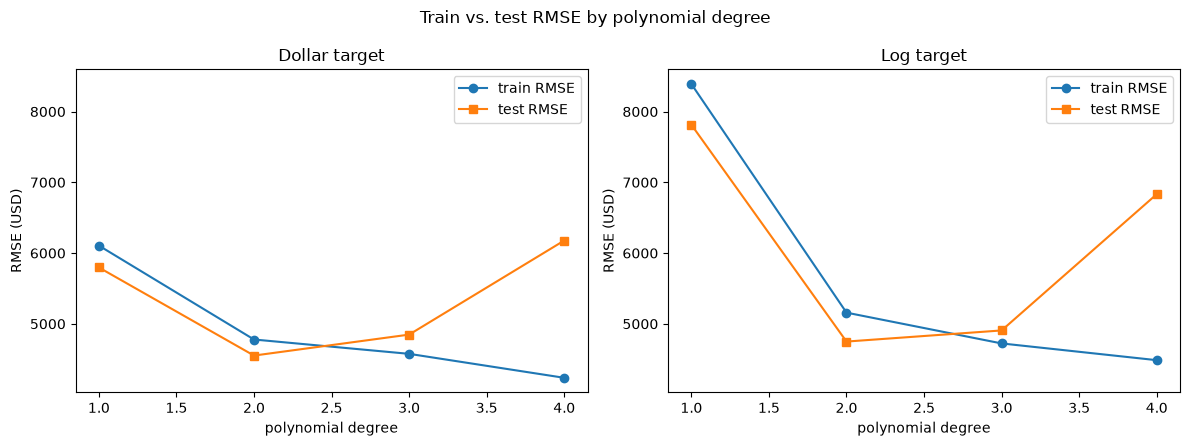

In [35]:
# === Section 6. Detect Over- and Under-Fitting ===

"""Sweep polynomial degree on each target, tracking train and test RMSE.

WHY: Higher degrees add interaction and curvature terms. Watching train and
test RMSE diverge shows where added complexity stops helping and starts
overfitting. Run once per target, then compare the best degree of each.

Standardizing is inside the loop: with eight features, high-degree terms reach
very different magnitudes, and scaling keeps the fit numerically stable.
Degrees are swept 1 to 4 because term count grows fast with eight features
(degree 4 is already 494 terms).
"""

MAX_SWEEP: Final[int] = 4
degrees: list[int] = list(range(1, MAX_SWEEP + 1))


def sweep_target(
    y_tr: np.ndarray, y_te: np.ndarray, log_space: bool
) -> tuple[list[float], list[float]]:
    """Return train and test RMSE in dollars across degrees for one target."""
    train_out: list[float] = []
    test_out: list[float] = []
    fit_tr = np.log1p(y_tr) if log_space else y_tr
    for degree in degrees:
        poly = PolynomialFeatures(degree=degree, include_bias=False)
        scaler = StandardScaler()
        Xtr = scaler.fit_transform(poly.fit_transform(X_train))
        Xte = scaler.transform(poly.transform(X_test))
        m = LinearRegression().fit(Xtr, fit_tr)
        pred_tr = np.expm1(m.predict(Xtr)) if log_space else m.predict(Xtr)
        pred_te = np.expm1(m.predict(Xte)) if log_space else m.predict(Xte)
        train_out.append(float(np.sqrt(np.mean((y_tr - pred_tr) ** 2))))
        test_out.append(float(np.sqrt(np.mean((y_te - pred_te) ** 2))))
    return train_out, test_out


# Sweep A: dollar target
dollar_train, dollar_test = sweep_target(y_train, y_test, log_space=False)
LOG.info("Sweep A, dollar target (RMSE in dollars):")
for d, tr, te in zip(degrees, dollar_train, dollar_test, strict=True):
    LOG.info(f"  degree={d}  train RMSE={tr:.1f}  test RMSE={te:.1f}")

# Sweep B: log target, evaluated back in dollars
log_train, log_test = sweep_target(y_train, y_test, log_space=True)
LOG.info("Sweep B, log target (RMSE in dollars):")
for d, tr, te in zip(degrees, log_train, log_test, strict=True):
    LOG.info(f"  degree={d}  train RMSE={tr:.1f}  test RMSE={te:.1f}")

# Plot both sweeps side by side, on a shared y-axis for direct comparison.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

axes[0].plot(degrees, dollar_train, marker="o", label="train RMSE")
axes[0].plot(degrees, dollar_test, marker="s", label="test RMSE")
axes[0].set_xlabel("polynomial degree")
axes[0].set_ylabel("RMSE (USD)")
axes[0].set_title("Dollar target")
axes[0].legend()

axes[1].plot(degrees, log_train, marker="o", label="train RMSE")
axes[1].plot(degrees, log_test, marker="s", label="test RMSE")
axes[1].set_xlabel("polynomial degree")
axes[1].set_ylabel("RMSE (USD)")
axes[1].set_title("Log target")
axes[1].tick_params(labelleft=True)
axes[1].legend()

fig.suptitle("Train vs. test RMSE by polynomial degree")
fig.tight_layout()
plt.savefig("../docs/images/degree_sweep_insurance.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation

Both sweeps tell the same story. For the dollar target, test RMSE drops sharply
from 5,796 at degree 1 to 4,551 at degree 2, then rises to 4,847 at degree 3 and
6,177 at degree 4. Training error keeps falling the whole way, from 6,106 down to
4,237, so the gap between train and test opens wide past degree 2. That widening
gap is overfitting: the model keeps improving on data it has seen while getting
worse on data it has not.

The log target follows the same shape. Test RMSE is lowest at degree 2 (4,749),
then climbs as training error keeps dropping. Both targets agree that degree 2 is
the right complexity, and both overfit beyond it.

Degree 2 is where the improvement comes from. Degree 1 is the plain linear model,
which the residual plots showed could not separate the high-charge cases. Degree
2 adds the products between features, including bmi and smoking together, so the
model can represent how those act in combination rather than separately. That is
the structure the linear residuals were missing, and capturing it pulls dollar
test RMSE down by more than 1,200.

Comparing the two winners settles the log question. At degree 2 the dollar target
reaches 4,551 and the log target 4,749, so the dollar model is slightly better.
The log transform, which looked promising against the skew, ends up behind once
polynomial terms are available. The gain came from added complexity, not from
transforming the target.

The best model is the dollar target at degree 2, with a test RMSE of 4,551, down
from 5,796 for the degree 1 linear model.

## Section 7. Regularization

The degree 2 model uses 44 features and starts to overfit by degree 3.
Regularization adds a penalty on large coefficients, which can reduce overfitting
by keeping the model from leaning too hard on any single term.

This section compares three models at degree 2 on the same standardized features:
plain least squares, Ridge, and ElasticNet. Ridge penalizes the squared size of
the coefficients. ElasticNet mixes that with a penalty on their absolute size,
which can drive some coefficients to zero. The penalty strength, alpha, is chosen
by cross-validation rather than fixed by hand.

In [36]:
# === Section 7. Regularization ===

"""Compare plain, Ridge, and ElasticNet at degree 2 and degree 3.

WHY: Regularization penalizes large coefficients to control overfitting. Degree 2
barely overfit, so it should help little there. Degree 3 overfit clearly in the
sweep, so it is the real test of whether regularization helps. alpha is tuned by
cross-validation. Features are standardized. Results are test-set R-squared and
RMSE in dollars.
"""

alphas = np.logspace(-2, 3, 20)


def build_features(degree: int) -> tuple[np.ndarray, np.ndarray]:
    """Standardized polynomial features for a given degree (fit on train only)."""
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(poly.fit_transform(X_train))
    Xte = scaler.transform(poly.transform(X_test))
    return Xtr, Xte


def evaluate(model, Xtr, Xte) -> tuple[float, float, str]:
    """Fit, then return test R-squared, test RMSE (dollars), and chosen alpha."""
    model.fit(Xtr, y_train)
    pred = model.predict(Xte)
    r2 = float(model.score(Xte, y_test))
    rmse = float(np.sqrt(np.mean((y_test - pred) ** 2)))
    alpha = f"alpha={model.alpha_:.3g}" if hasattr(model, "alpha_") else "no penalty"
    return r2, rmse, alpha


def make_models() -> dict:
    return {
        "Plain (least squares)": LinearRegression(),
        "Ridge (CV-tuned)": RidgeCV(alphas=alphas),
        "ElasticNet (CV-tuned)": ElasticNetCV(
            alphas=alphas,
            l1_ratio=[0.1, 0.5, 0.9],
            max_iter=100000,
            random_state=RANDOM_STATE,
        ),
    }


for degree in [2, 3]:
    Xtr, Xte = build_features(degree)
    LOG.info(f"Degree {degree} comparison (test set):")
    for name, model in make_models().items():
        r2, rmse, alpha = evaluate(model, Xtr, Xte)
        LOG.info(f"  {name:24} R-squared={r2:.4f}  RMSE={rmse:.1f}  ({alpha})")

2026-07-24 21:21:38 | INFO | M04 Phase 5 | Degree 2 comparison (test set):
2026-07-24 21:21:38 | INFO | M04 Phase 5 |   Plain (least squares)    R-squared=0.8666  RMSE=4551.1  (no penalty)
2026-07-24 21:21:38 | INFO | M04 Phase 5 |   Ridge (CV-tuned)         R-squared=0.8665  RMSE=4551.7  (alpha=1.27)
2026-07-24 21:21:38 | INFO | M04 Phase 5 |   ElasticNet (CV-tuned)    R-squared=0.8666  RMSE=4551.2  (alpha=0.01)
2026-07-24 21:21:38 | INFO | M04 Phase 5 | Degree 3 comparison (test set):
2026-07-24 21:21:38 | INFO | M04 Phase 5 |   Plain (least squares)    R-squared=0.8486  RMSE=4847.5  (no penalty)
2026-07-24 21:21:39 | INFO | M04 Phase 5 |   Ridge (CV-tuned)         R-squared=0.8607  RMSE=4650.9  (alpha=14.4)
2026-07-24 21:21:42 | INFO | M04 Phase 5 |   ElasticNet (CV-tuned)    R-squared=0.8610  RMSE=4645.4  (alpha=0.0183)


### Interpretation

At degree 2, regularization changed almost nothing. Plain least squares, Ridge,
and ElasticNet all reached a test R-squared of about 0.867 and an RMSE near
4,551, and cross-validation chose very small penalties. This is the expected
result when a model is not overfitting: the degree 2 fit already generalizes
well, so there is little for a penalty to correct.

Degree 3 is where regularization showed its value. Plain least squares overfit,
with test R-squared falling to 0.8486 and RMSE rising to 4,847.5. Ridge recovered
most of that loss (R-squared 0.8607, RMSE 4,650.9) and ElasticNet slightly more
(R-squared 0.8610, RMSE 4,645.4). Cross-validation chose a much larger penalty
for Ridge, 14.4 against 1.27 at degree 2, so the model asked for more restraint
exactly where it was overfitting.

Even so, the rescued degree 3 model never beats degree 2. Regularization can undo
the cost of unnecessary complexity, but it cannot create signal the data does not
hold. The best model remains the degree 2 fit at a test R-squared of 0.8666 and
an RMSE of 4,551.

## Section 8. Summary and Next Steps

In [37]:
# === Python Summary ===

"""Record the final model and its test performance."""
LOG.info("========================")
LOG.info("SUMMARY")
LOG.info("========================")
LOG.info(f"Dataset:  insurance.csv  ({df.shape[0]} rows)")
LOG.info(
    f"Features: {len(FEATURE_COLS)} (after encoding)  ->  Target: {TARGET_COL}  (regression)"
)
LOG.info("Best model: degree 2 polynomial, dollar target, plain least squares")
LOG.info("  Test R-squared: 0.8666   Test RMSE: 4551.1")
LOG.info("Baselines for comparison:")
LOG.info("  Degree 1 linear (dollars): RMSE 5796.3")
LOG.info("  Degree 1 linear (log target): RMSE 7814.1")
LOG.info("========================")

2026-07-24 21:21:42 | INFO | M04 Phase 5 | ========================
2026-07-24 21:21:42 | INFO | M04 Phase 5 | SUMMARY
2026-07-24 21:21:42 | INFO | M04 Phase 5 | ========================
2026-07-24 21:21:42 | INFO | M04 Phase 5 | Dataset:  insurance.csv  (1338 rows)
2026-07-24 21:21:42 | INFO | M04 Phase 5 | Features: 8 (after encoding)  ->  Target: charges  (regression)
2026-07-24 21:21:42 | INFO | M04 Phase 5 | Best model: degree 2 polynomial, dollar target, plain least squares
2026-07-24 21:21:42 | INFO | M04 Phase 5 |   Test R-squared: 0.8666   Test RMSE: 4551.1
2026-07-24 21:21:42 | INFO | M04 Phase 5 | Baselines for comparison:
2026-07-24 21:21:42 | INFO | M04 Phase 5 |   Degree 1 linear (dollars): RMSE 5796.3
2026-07-24 21:21:42 | INFO | M04 Phase 5 |   Degree 1 linear (log target): RMSE 7814.1
2026-07-24 21:21:42 | INFO | M04 Phase 5 | ========================



### Custom Narrative

I set out to predict individual medical insurance charges from six features:
age, bmi, children, sex, smoker, and region. The three categorical columns were
one-hot encoded, giving eight numeric features. The target, charges, is right-
skewed, with a mean of 13,270 dollars pulled well above the median by a long
tail of expensive cases.

A plain linear model on all eight features reached a test R-squared of 0.7836
with an RMSE of 5,796 dollars. The residual plot showed the model was missing
real structure: the errors funneled wider as predicted charges rose, and at high
charges the points split into two separate groups the model could not tell apart.

I tried two responses. Log-transforming the target addressed the skew but made
dollar RMSE worse, because compressing the scale traded accuracy on expensive
cases for a tighter fit on common ones. Adding polynomial features worked. Degree
2, which introduces the products between features, dropped test RMSE to 4,551 and
raised R-squared to 0.8666. Those product terms let the model represent how
features act in combination rather than separately, which is what the linear
model could not do. Beyond degree 2 the model overfit: training error kept
falling while test error rose.

I also tested Ridge and ElasticNet regularization. At degree 2 they changed
almost nothing, because the model was not overfitting and cross-validation chose
near-zero penalties. At degree 3, where the model did overfit, plain least
squares rose to an RMSE of 4,847, and regularization pulled it back to about
4,650, though still short of degree 2. Regularization can undo some of the cost
of unnecessary complexity, but it cannot create signal the data does not hold.

The final model is the degree 2 polynomial on the dollar target: test R-squared
0.8666, RMSE 4,551. Smoking is by far the strongest predictor, adding about
23,600 dollars to predicted charges, and the products the degree 2 model added
are what let it capture structure the plain linear model missed.

### Next Steps

The clearest next step is to examine the two groups the residuals revealed at
high charges. The plot showed the model splitting expensive cases into two
separate bands, and identifying what distinguishes them, beyond smoking status,
would show which combinations of features the degree 2 terms are capturing and
whether a more targeted feature would serve better than raising the polynomial
degree.
